# Part 1 Optimize function f(x) = x^2 + 3x + 2 

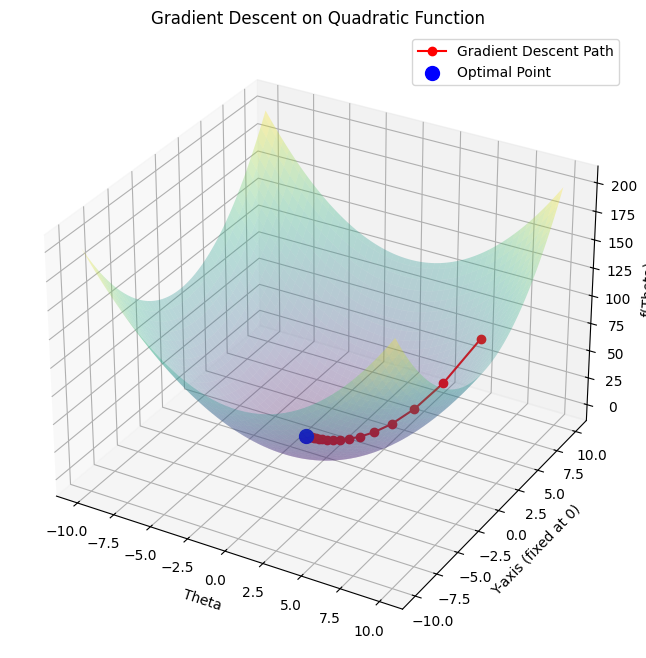

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Gradient descent function
#   theta = wektor parametrów modelu ktore model aktualizuje
def gradient_descent(f, grad_f, theta_init, learning_rate, iterations):
    theta = theta_init
    trajectory = [theta]  # Store theta values for visualization
    for i in range(iterations):
        theta -= learning_rate * grad_f(theta)
        trajectory.append(theta)
    return theta, trajectory

# Quadratic function and its gradient
# chodzi o f jak w poleceniu i grad_f to jest * (pri) np x^2 = 2x
# lambda znaczy to samo co => definiowanie funkcji
f = lambda x: x**2 + 3*x+2
grad_f = lambda x: 2*x + 3

# Parameters for gradient descent
theta_init = 10.0
learning_rate = 0.1
iterations = 20

# Perform gradient descent
optimal_theta, trajectory = gradient_descent(f, grad_f, theta_init, learning_rate, iterations)

# Create a grid for visualization
x = np.linspace(-10, 10, 400)
y = f(x)

# Prepare 3D visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the quadratic surface
X = np.linspace(-10, 10, 100)
Y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(X, Y)
Z = X**2 + Y**2

ax.plot_surface(X, Y, Z, alpha=0.3, cmap='viridis')

# Plot trajectory
trajectory_x = trajectory
trajectory_y = np.zeros_like(trajectory)  # Single variable optimization
trajectory_z = [f(t) for t in trajectory]

ax.plot(trajectory_x, trajectory_y, trajectory_z, color='red', marker='o', label='Gradient Descent Path')
ax.scatter(optimal_theta, 0, f(optimal_theta), color='blue', s=100, label='Optimal Point')

# Labeling the plot
ax.set_xlabel("Theta")
ax.set_ylabel("Y-axis (fixed at 0)")
ax.set_zlabel("f(Theta)")
ax.set_title("Gradient Descent on Quadratic Function")
ax.legend()

plt.show()
# bazowy obrazek to jest parabola bo X^2+Y^2
# i theta mimo ze z kazda iteracja z kolejnym razem jest mniejsza i powinna isc do dolu to wizualnie idzie do gury
# bo to idzie w dol wzgedem tej paraboli

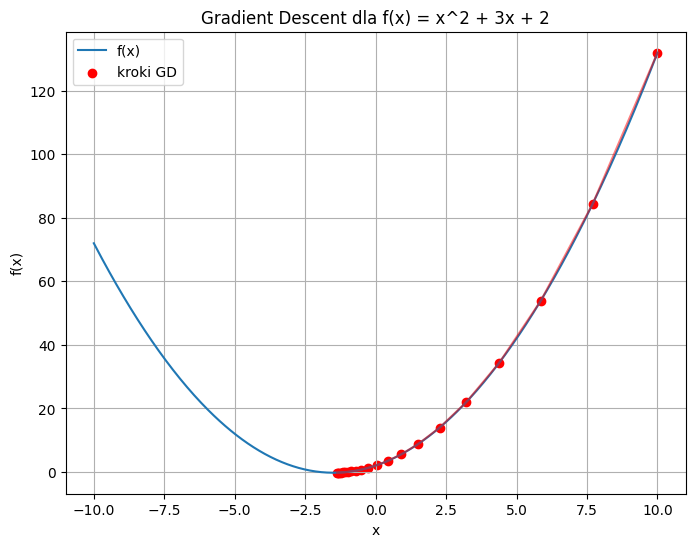

In [5]:
# Wykres 2D (to jest to, czego chcą)
plt.figure(figsize=(8,6))

# wykres funkcji
x_vals = np.linspace(-10, 10, 400)
plt.plot(x_vals, f(x_vals), label="f(x)")

# punkty gradient descent
plt.scatter(trajectory, [f(t) for t in trajectory], color='red', label='kroki GD')

# opcjonalnie linie między punktami
plt.plot(trajectory, [f(t) for t in trajectory], color='red', alpha=0.5)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent dla f(x) = x^2 + 3x + 2")
plt.legend()
plt.grid()

plt.show()

# Part 2 Neural Network for Linear Regression

Epoka 1/3, Błąd: 0.2731
Epoka 2/3, Błąd: 0.1782
Epoka 3/3, Błąd: 0.1284


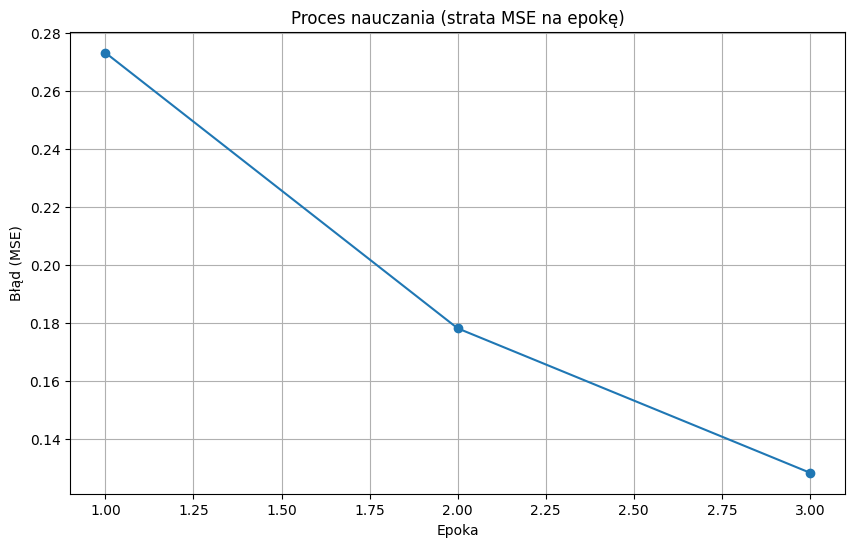

Błąd na zbiorze testowym (MSE): 0.1238
Prognozowane wartości dla nowych danych:
Przykład 1: 0.3373
Przykład 2: 0.3852
Przykład 3: 0.5130
Przykład 4: 0.4726
Przykład 5: 0.3570


In [7]:
# z wizualizacją nauczania, ewaluacją i prognozowaniem
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST

# Definicja modelu
class SimpleNN(nn.Module):
    def __init__(self):
        #wejscie 10 cech i 64 neurony , wejsice 64 cech i 1 wynik
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(10, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
         # brak aktywacji → liczba
        return self.fc2(x)

# Inicjalizacja modelu
model = SimpleNN()

# Funkcja kosztu i optymalizator 
# MSELoss to regresja
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Dane treningowe
X_train = torch.rand(100, 10)
y_train = torch.rand(100, 1)

# Dane testowe
X_test = torch.rand(20, 10)
y_test = torch.rand(20, 1)

# Parametry trenowania
epochs = 3
batch_size = 32
num_batches = len(X_train) // batch_size
loss_history = []

# Proces nauczania
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for i in range(0, len(X_train), batch_size):
        # Pobranie batcha
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        # Forward pass
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Średni błąd dla epoki
    epoch_loss /= num_batches
    loss_history.append(epoch_loss)
    print(f"Epoka {epoch+1}/{epochs}, Błąd: {epoch_loss:.4f}")

# Wizualizacja procesu nauczania
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o')
plt.xlabel('Epoka')
plt.ylabel('Błąd (MSE)')
plt.title('Proces nauczania (strata MSE na epokę)')
plt.grid()
plt.show()

# Ewaluacja na zbiorze testowym
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test)
    test_loss = loss_fn(y_test_pred, y_test).item()
    print(f"Błąd na zbiorze testowym (MSE): {test_loss:.4f}")

# Prognozowanie dla nowych danych
new_data = torch.rand(5, 10)  # 5 nowych próbek
with torch.no_grad():
    predictions = model(new_data)

# Wyświetlenie wyników prognozowania
print("Prognozowane wartości dla nowych danych:")
for i, prediction in enumerate(predictions):
    print(f"Przykład {i + 1}: {prediction.item():.4f}")


# Part 3 Convolutional Neural Network (CNN)

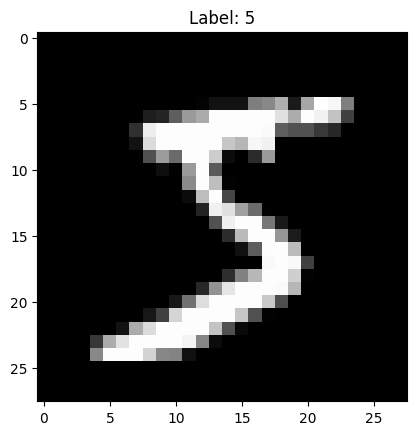

torch.Size([60000, 28, 28])


In [1]:
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt

dataset = MNIST(
    root="./data",
    train=True,
    download=True,
)

plt.imshow(dataset.data[0], cmap="gray")
plt.title(f"Label: {dataset.targets[0]}")
plt.show()
print(dataset.data.size())

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

from tqdm import tqdm
from torchmetrics.classification import Accuracy

# DATA
batch_size = 64

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="dataset/", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="dataset/", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# MODEL
class CNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

# DEVICE
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN().to(device)

# LOSS + OPT
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# TRAINING
num_epochs = 5

for epoch in range(num_epochs):
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    model.train()

    for data, targets in tqdm(train_loader):
        data, targets = data.to(device), targets.to(device)

        scores = model(data)
        loss = criterion(scores, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# TEST
accuracy = Accuracy(task="multiclass", num_classes=10).to(device)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        accuracy.update(preds, labels)

print("Test accuracy:", accuracy.compute().item())

# Part 2